# LSTM Autoencoder — MPLS Network Anomaly Detection

**Goal**: Train an LSTM autoencoder to detect network anomalies from time-series telemetry.
Reconstruction error = anomaly score. Higher error = more anomalous.

**Data**: `telemetry_train.csv` — 3 days of per-node telemetry at 2s intervals (10 nodes, ~1.3M rows).
**NUMERIC_COLS (23)**: bytes_in/out, packets_in/out, errors_in, drops_in/out, utilization_pct,
bgp_sessions_active, bgp_prefixes_received, bgp_updates_per_min, bgp_withdrawals_per_min,
ospf_spf_runs, ldp_sessions_active, mpls_lsp_count, mpls_label_table_size, vpn_routes_count,
cpu_load_pct, memory_used_pct, queue_depth, latency_ms, jitter_ms, packet_loss_pct

**Architecture**: LSTMEncoder(23→256, 3 layers) → LSTMDecoder(256→23, 2 layers, seq_len=60)

**Key design**: Autoencoder trained on **normal sequences only**. Anomalies yield higher reconstruction error.

In [1]:
# Cell 1: Install dependencies (run once)
# torch-geometric and optuna are not pre-installed on Kaggle
!pip install -q optuna
# torch is pre-installed; torch-geometric is NOT needed for LSTM

import torch
print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU count: {torch.cuda.device_count()}")

PyTorch 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU count: 2


In [2]:
# Cell 2: Imports
import os, sys, json, gc, warnings, random, zipfile
from pathlib import Path
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve,
                             confusion_matrix, classification_report)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print(f"PyTorch {torch.__version__}, CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PyTorch 2.10.0+cu128, CUDA available: True
Using device: cuda


In [6]:
# Cell 3: Configuration
class Config:
    # --- Dataset paths (update to match your Kaggle dataset name) ---
    data_dir = '/kaggle/input/datasets/visheshaggarwal/mpls-network-telemetry/'
    train_csv = os.path.join(data_dir, 'telemetry_train.csv')
    val_csv = os.path.join(data_dir, 'telemetry_val.csv')

    # --- Sequence parameters ---
    seq_len = 60          # 60 timesteps = 2 minutes at 2s intervals
    stride = 10           # stride for sliding window (lower = more data augmentation)

    # --- NUMERIC_COLS — exactly as defined by the data generator (in order) ---
    # These are the 23 aggregate columns from NUMERIC_COLS in network_gen.py
    numeric_cols = [
        'bytes_in', 'bytes_out', 'packets_in', 'packets_out',
        'errors_in', 'drops_in', 'drops_out', 'utilization_pct',
        'bgp_sessions_active', 'bgp_prefixes_received',
        'bgp_updates_per_min', 'bgp_withdrawals_per_min',
        'ospf_spf_runs',
        'ldp_sessions_active', 'mpls_lsp_count',
        'mpls_label_table_size', 'vpn_routes_count',
        'cpu_load_pct', 'memory_used_pct', 'queue_depth',
        'latency_ms', 'jitter_ms', 'packet_loss_pct',
    ]
    n_features = len(numeric_cols)  # 23

    # --- Model hyperparams (tuned by Optuna; these are sensible defaults) ---
    hidden_dim = 256
    num_layers_enc = 3
    num_layers_dec = 2
    dropout = 0.2

    # --- Training ---
    batch_size = 512
    max_epochs = 100
    learning_rate = 1e-3
    weight_decay = 1e-5
    early_stopping_patience = 10

    # --- Optuna ---
    n_trials = 30

    # --- Output ---
    model_dir = '/kaggle/working'

cfg = Config()
print(f"Features: {cfg.n_features}, seq_len: {cfg.seq_len}")
print(f"Columns: {cfg.numeric_cols}")

Features: 23, seq_len: 60
Columns: ['bytes_in', 'bytes_out', 'packets_in', 'packets_out', 'errors_in', 'drops_in', 'drops_out', 'utilization_pct', 'bgp_sessions_active', 'bgp_prefixes_received', 'bgp_updates_per_min', 'bgp_withdrawals_per_min', 'ospf_spf_runs', 'ldp_sessions_active', 'mpls_lsp_count', 'mpls_label_table_size', 'vpn_routes_count', 'cpu_load_pct', 'memory_used_pct', 'queue_depth', 'latency_ms', 'jitter_ms', 'packet_loss_pct']


In [7]:
# Cell 4: Data Loading
print("Loading training data...")
train_df = pd.read_csv(cfg.train_csv)
train_df['timestamp'] = pd.to_datetime(train_df['timestamp'])
print(f"Train shape: {train_df.shape}")
print(f"Date range: {train_df['timestamp'].min()} → {train_df['timestamp'].max()}")
print(f"Nodes: {sorted(train_df['node_id'].unique())}")
print(f"Anomaly rate: {train_df['is_anomaly'].mean():.3%}")

print("\nLoading validation data...")
val_df = pd.read_csv(cfg.val_csv)
val_df['timestamp'] = pd.to_datetime(val_df['timestamp'])
print(f"Val shape: {val_df.shape}")
print(f"Val anomaly rate: {val_df['is_anomaly'].mean():.3%}")

# Sanity check: verify all expected columns are present
missing = [c for c in cfg.numeric_cols if c not in train_df.columns]
if missing:
    raise ValueError(f"Missing columns in train CSV: {missing}")
print(f"\nAll {cfg.n_features} NUMERIC_COLS present. ✓")

# Check for NaNs
nan_count = train_df[cfg.numeric_cols].isna().sum().sum()
print(f"NaN values in numeric cols: {nan_count}")
if nan_count > 0:
    train_df[cfg.numeric_cols] = train_df[cfg.numeric_cols].fillna(0)
    val_df[cfg.numeric_cols] = val_df[cfg.numeric_cols].fillna(0)
    print("  → Filled NaNs with 0")

Loading training data...
Train shape: (1296000, 92)
Date range: 2026-01-01 00:00:00 → 2026-01-03 23:59:58
Nodes: ['CE-B1', 'CE-B2', 'CE-B3', 'CE-DC1', 'CE-DC2', 'P-1', 'P-2', 'P-3', 'PE-1', 'PE-2']
Anomaly rate: 4.838%

Loading validation data...
Val shape: (432000, 92)
Val anomaly rate: 5.903%

All 23 NUMERIC_COLS present. ✓
NaN values in numeric cols: 0


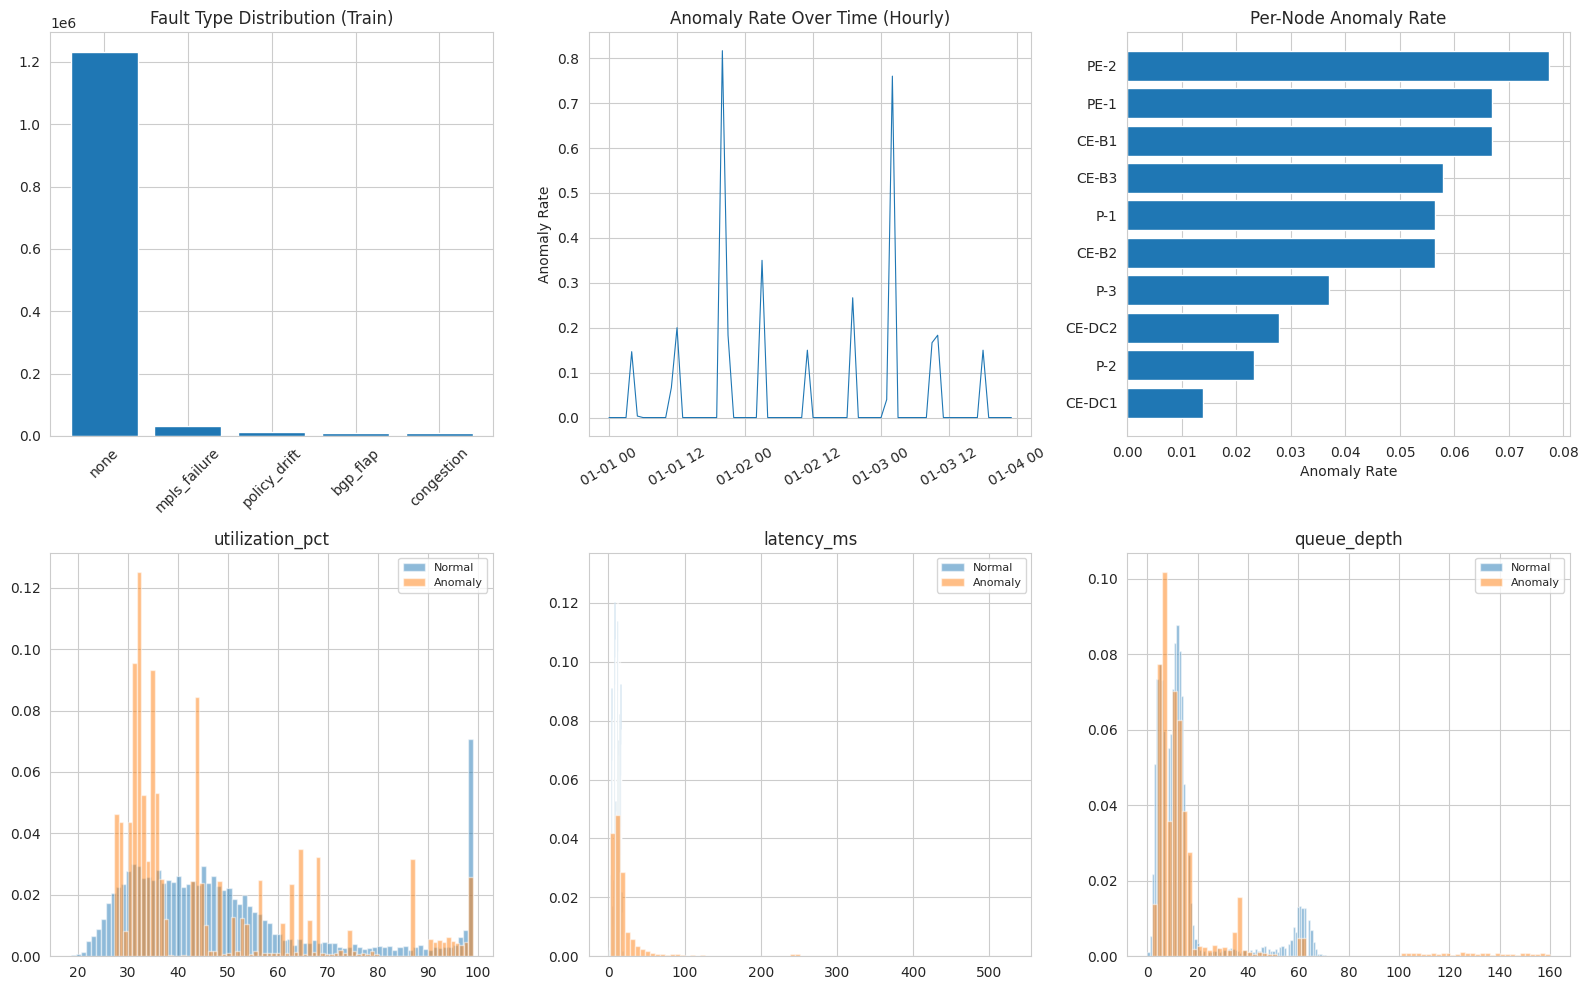

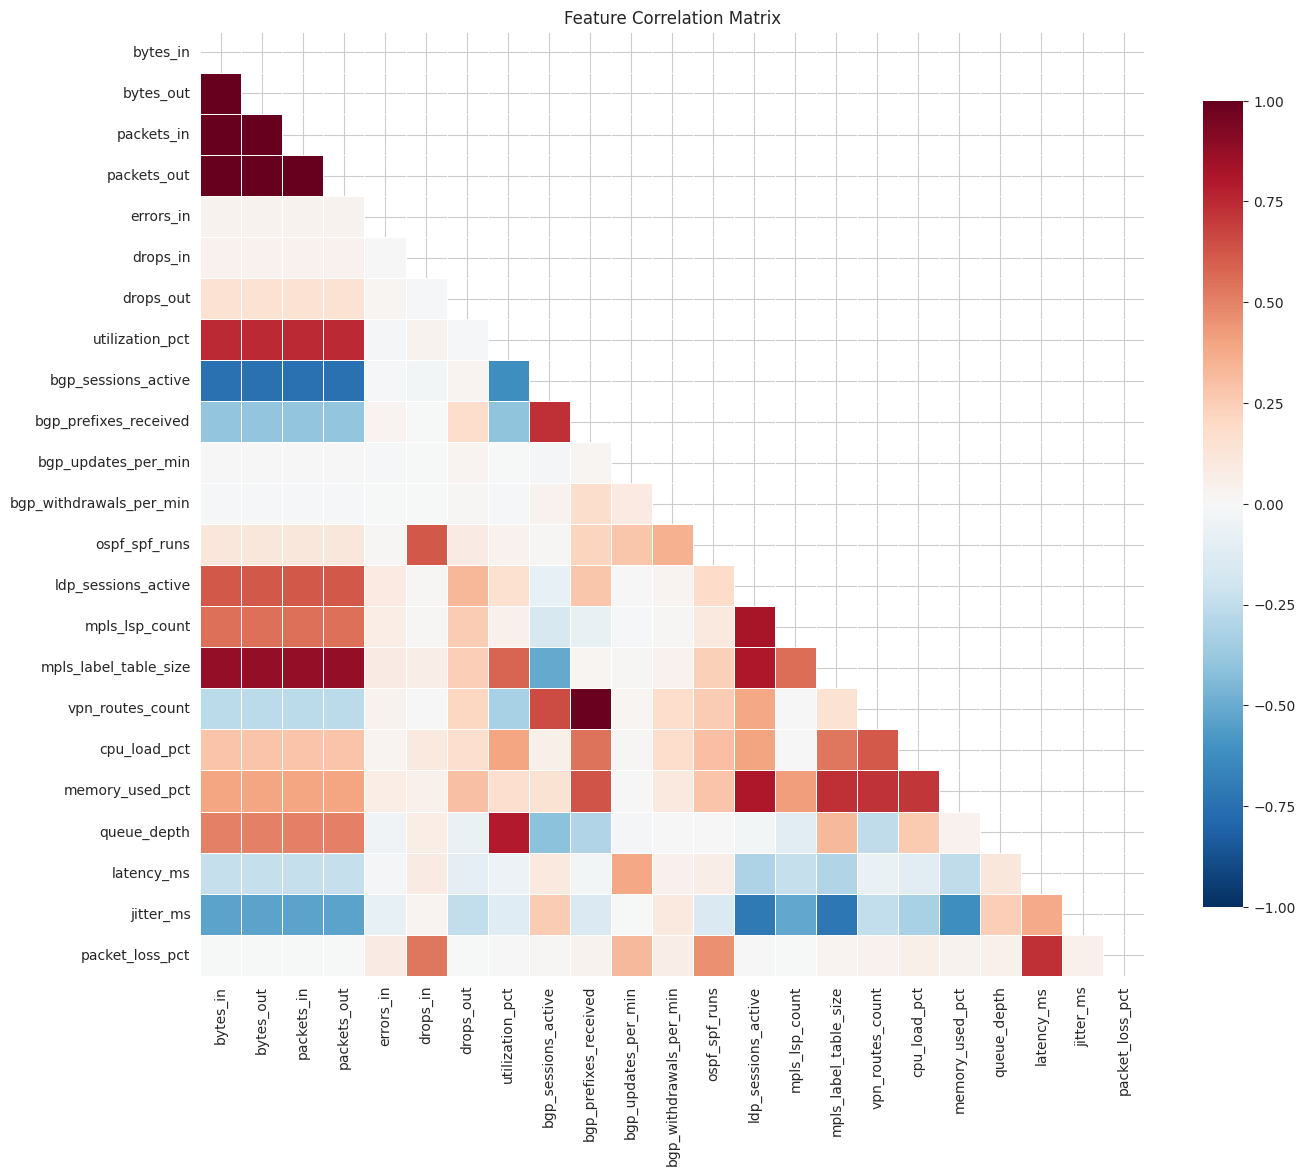

In [8]:
# Cell 5: Exploratory Data Analysis

# 5a — Fault distribution in training set
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

fault_counts = train_df['fault_type'].value_counts()
axes[0, 0].bar(fault_counts.index, fault_counts.values)
axes[0, 0].set_title('Fault Type Distribution (Train)')
axes[0, 0].tick_params(axis='x', rotation=45)

# 5b — Anomaly over time (binned hourly)
train_df['hour'] = train_df['timestamp'].dt.floor('h')
hourly_anom = train_df.groupby('hour')['is_anomaly'].mean()
axes[0, 1].plot(hourly_anom.index, hourly_anom.values, linewidth=0.8)
axes[0, 1].set_title('Anomaly Rate Over Time (Hourly)')
axes[0, 1].set_ylabel('Anomaly Rate')
axes[0, 1].tick_params(axis='x', rotation=30)

# 5c — Per-node anomaly rate
node_anom = train_df.groupby('node_id')['is_anomaly'].mean().sort_values()
axes[0, 2].barh(node_anom.index, node_anom.values)
axes[0, 2].set_title('Per-Node Anomaly Rate')
axes[0, 2].set_xlabel('Anomaly Rate')

# 5d-5f — Distribution of 3 key metrics (normal vs anomalous)
key_metrics_eda = ['utilization_pct', 'latency_ms', 'queue_depth']
for i, m in enumerate(key_metrics_eda):
    ax = axes[1, i]
    n_normal = (train_df['is_anomaly'] == 0).sum()
    n_anom = (train_df['is_anomaly'] == 1).sum()
    normal_data = train_df[train_df['is_anomaly'] == 0][m].sample(min(10000, n_normal), random_state=42)
    anom_data = train_df[train_df['is_anomaly'] == 1][m].sample(min(10000, n_anom), random_state=42)
    ax.hist(normal_data, bins=80, alpha=0.5, label='Normal', density=True)
    ax.hist(anom_data, bins=80, alpha=0.5, label='Anomaly', density=True)
    ax.set_title(m)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 5g — Correlation heatmap of NUMERIC_COLS
plt.figure(figsize=(14, 12))
corr = train_df[cfg.numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [9]:
# Cell 6: Feature Engineering — Build Sequences
# IMPORTANT: AE is trained on NORMAL sequences only.
# Anomalous sequences are kept separate for threshold calibration.

def build_sequences(df, numeric_cols, seq_len=60, stride=10):
    """
    Build (seq_len, n_features) sequences with sliding window.
    Returns:
        X: (n_sequences, seq_len, n_features) numpy array
        y: (n_sequences,) binary labels (1 if ANY timestep in window is anomalous)
        fault_meta: (n_sequences,) list of fault_type arrays per window
        timestamps: (n_sequences,) start timestamp of each window
        node_ids: (n_sequences,) node_id per window
    """
    sequences = []
    labels = []
    fault_meta = []
    timestamps = []
    node_ids = []

    for node_id, group in df.groupby('node_id'):
        group = group.sort_values('timestamp').reset_index(drop=True)
        values = group[numeric_cols].values.astype(np.float32)
        n = len(values)
        if n < seq_len:
            continue

        for start in range(0, n - seq_len + 1, stride):
            seq = values[start:start + seq_len]
            window_labels = group.iloc[start:start + seq_len]['is_anomaly'].values
            window_faults = group.iloc[start:start + seq_len]['fault_type'].values

            sequences.append(seq)
            labels.append(1 if window_labels.sum() > 0 else 0)
            fault_meta.append(window_faults)
            timestamps.append(group.iloc[start]['timestamp'])
            node_ids.append(node_id)

    return (
        np.array(sequences, dtype=np.float32),
        np.array(labels, dtype=np.int32),
        fault_meta,
        timestamps,
        node_ids,
    )


print("Building training sequences...")
X_train_raw, y_train, fault_train, ts_train, nodes_train = build_sequences(
    train_df, cfg.numeric_cols, cfg.seq_len, cfg.stride,
)
print(f"Train sequences: {X_train_raw.shape}, anomaly rate: {y_train.mean():.3%}")

print("\nBuilding validation sequences...")
X_val_raw, y_val, fault_val, ts_val, nodes_val = build_sequences(
    val_df, cfg.numeric_cols, cfg.seq_len, cfg.stride,
)
print(f"Val sequences: {X_val_raw.shape}, anomaly rate: {y_val.mean():.3%}")

# Split sequences into normal-only (for AE training) and full (for evaluation)
normal_train_mask = y_train == 0
X_train_normal = X_train_raw[normal_train_mask]   # AE training data (normal only)
print(f"\nNormal training sequences: {len(X_train_normal):,} / {len(X_train_raw):,}")

Building training sequences...
Train sequences: (129550, 60, 23), anomaly rate: 5.033%

Building validation sequences...
Val sequences: (43150, 60, 23), anomaly rate: 6.141%

Normal training sequences: 123,030 / 129,550


In [10]:
# Cell 7: Normalization
# Scaler is fit on NORMAL training sequences only → cleaner statistics
# We reshape to (n_samples * seq_len, n_features) for StandardScaler.

# Fit scaler on normal training data only
X_train_normal_2d = X_train_normal.reshape(-1, cfg.n_features)
scaler = StandardScaler()
X_train_normal_norm = scaler.fit_transform(X_train_normal_2d).reshape(X_train_normal.shape)

# Transform full train and val sets using the same scaler
X_train_norm = scaler.transform(X_train_raw.reshape(-1, cfg.n_features)).reshape(X_train_raw.shape)
X_val_norm = scaler.transform(X_val_raw.reshape(-1, cfg.n_features)).reshape(X_val_raw.shape)

print(f"Normal train (for AE): mean~{X_train_normal_norm.mean():.4f}, std~{X_train_normal_norm.std():.4f}")
print(f"Full train:            mean~{X_train_norm.mean():.4f}, std~{X_train_norm.std():.4f}")
print(f"Val:                   mean~{X_val_norm.mean():.4f}, std~{X_val_norm.std():.4f}")

# Save scaler for inference
scaler_path = os.path.join(cfg.model_dir, 'lstm_scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

Normal train (for AE): mean~0.0000, std~1.0000
Full train:            mean~4.4516, std~224.4238
Val:                   mean~6.4319, std~248.7866
Scaler saved to /kaggle/working/lstm_scaler.pkl


In [36]:
# Cell 8: Dataset & Model Definition

class SequenceDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y) if y is not None else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]


class LSTMEncoder(nn.Module):
    def __init__(self, n_features, hidden_dim, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            n_features, hidden_dim, num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0,
        )

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return h_n[-1]  # last layer hidden state: (batch, hidden_dim)


class LSTMDecoder(nn.Module):
    def __init__(self, n_features, hidden_dim, num_layers, seq_len):
        super().__init__()
        self.seq_len = seq_len
        self.lstm = nn.LSTM(
            hidden_dim, hidden_dim, num_layers,
            batch_first=True, dropout=0.2 if num_layers > 1 else 0,
        )
        self.linear = nn.Linear(hidden_dim, n_features)

    def forward(self, z):
        z = z.unsqueeze(1).repeat(1, self.seq_len, 1)  # (batch, seq_len, hidden_dim)
        out, _ = self.lstm(z)
        return self.linear(out)  # (batch, seq_len, n_features)


class LSTMAutoencoder(nn.Module):
    def __init__(self, n_features, hidden_dim,
                 num_layers_enc=3, num_layers_dec=2, dropout=0.2, seq_len=60):
        super().__init__()
        self.encoder = LSTMEncoder(n_features, hidden_dim, num_layers_enc, dropout)
        self.decoder = LSTMDecoder(n_features, hidden_dim, num_layers_dec, seq_len)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

    # BEFORE (line ~401)
    # def reconstruction_error(self, x):
    #     """Per-sample MSE. Shape: (batch,)"""
    #     x_hat = self.forward(x)
    #     return torch.mean((x - x_hat) ** 2, dim=(1, 2))
    
    # AFTER
    def reconstruction_error(self, x):
        x_hat = self.forward(x)
        per_feature = torch.mean((x - x_hat) ** 2, dim=1)  # (batch, 23)
        return torch.max(per_feature, dim=1)[0]            # (batch,) — worst feature


# Quick parameter count sanity check
_test_model = LSTMAutoencoder(
    cfg.n_features, cfg.hidden_dim,
    cfg.num_layers_enc, cfg.num_layers_dec, cfg.dropout, cfg.seq_len
)
print(f"Default model parameters: {sum(p.numel() for p in _test_model.parameters()):,}")
del _test_model

Default model parameters: 1,872,663


In [12]:
# Cell 9: Training Utilities

def _unwrap(m):
    """Unwrap DataParallel to access underlying module."""
    return m.module if hasattr(m, 'module') else m


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        x = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)
        optimizer.zero_grad()
        x_hat = model(x)
        loss = criterion(x_hat, x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(_unwrap(model).parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_errors = []
    for batch in loader:
        x = batch[0].to(device) if isinstance(batch, (list, tuple)) else batch.to(device)
        x_hat = model(x)
        loss = criterion(x_hat, x)
        err = _unwrap(model).reconstruction_error(x)
        total_loss += loss.item() * x.size(0)
        all_errors.append(err.cpu())
    return total_loss / len(loader.dataset), torch.cat(all_errors).numpy()


def find_best_threshold(errors_normal, errors_anom):
    """Find threshold that maximises F1 score using precision-recall curve."""
    all_errors = np.concatenate([errors_normal, errors_anom])
    all_labels = np.concatenate([np.zeros_like(errors_normal), np.ones_like(errors_anom)])

    precisions, recalls, thresholds = precision_recall_curve(all_labels, all_errors)
    # Note: precisions and recalls have one more element than thresholds
    f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-10)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx], all_errors, all_labels

In [14]:
# Cell 10: Hyperparameter Tuning with Optuna
# Trains on normal sequences only; validates on normal-only val sequences.

# Separate normal vs anomalous validation sequences for threshold tuning
normal_val_mask = y_val == 0
X_val_normal_norm = X_val_norm[normal_val_mask]

# Use a subset for tuning speed
tune_train_size = min(10000, len(X_train_normal_norm))
tune_val_size = min(3000, len(X_val_normal_norm))
rng_tune = np.random.RandomState(42)
train_tune_idx = rng_tune.choice(len(X_train_normal_norm), tune_train_size, replace=False)
val_tune_idx = rng_tune.choice(len(X_val_normal_norm), tune_val_size, replace=False)
X_tune_train = X_train_normal_norm[train_tune_idx]
X_tune_val = X_val_normal_norm[val_tune_idx]


def objective(trial):
    # Suggest hyperparams
    hidden_dim = trial.suggest_categorical('hidden_dim', [128, 256, 384])
    num_layers_enc = trial.suggest_int('num_layers_enc', 2, 4)
    num_layers_dec = trial.suggest_int('num_layers_dec', 1, 3)
    lr = trial.suggest_float('lr', 5e-4, 3e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.1, 0.4)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-4, log=True)

    # Build model
    model = LSTMAutoencoder(
        n_features=cfg.n_features,
        hidden_dim=hidden_dim,
        num_layers_enc=num_layers_enc,
        num_layers_dec=num_layers_dec,
        dropout=dropout,
        seq_len=cfg.seq_len,
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    train_loader = DataLoader(
        SequenceDataset(X_tune_train, None),
        batch_size=cfg.batch_size, shuffle=True, num_workers=2, pin_memory=True,
    )
    val_loader = DataLoader(
        SequenceDataset(X_tune_val, None),
        batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=True,
    )

    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(30):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, _ = eval_epoch(model, val_loader, criterion, device)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 5:
                break

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    del model, optimizer, train_loader, val_loader
    gc.collect()
    torch.cuda.empty_cache()
    return best_val_loss


print("Starting Optuna hyperparameter search...")
print(f"Tuning on {len(X_tune_train):,} train / {len(X_tune_val):,} val sequences (normal only)")
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
)
study.optimize(objective, n_trials=15, show_progress_bar=True)

print(f"\nBest trial: {study.best_trial.number}")
print(f"Best val loss: {study.best_value:.6f}")
print(f"Best params: {study.best_params}")

# Store best params in config
best_params = study.best_params
cfg.hidden_dim = best_params['hidden_dim']
cfg.num_layers_enc = best_params['num_layers_enc']
cfg.num_layers_dec = best_params['num_layers_dec']
cfg.learning_rate = best_params['lr']
cfg.dropout = best_params['dropout']
cfg.weight_decay = best_params['weight_decay']

Starting Optuna hyperparameter search...
Tuning on 10,000 train / 3,000 val sequences (normal only)


  0%|          | 0/15 [00:00<?, ?it/s]


Best trial: 0
Best val loss: 0.278846
Best params: {'hidden_dim': 256, 'num_layers_enc': 3, 'num_layers_dec': 1, 'lr': 0.0006612372870684138, 'dropout': 0.11742508365045984, 'weight_decay': 5.39948440978744e-05}


In [15]:
# Cell 11: Optuna Visualization
fig = optuna.visualization.plot_optimization_history(study)
fig.update_layout(width=900, height=400)
fig.show()

fig2 = optuna.visualization.plot_param_importances(study)
fig2.update_layout(width=900, height=500)
fig2.show()

fig3 = optuna.visualization.plot_parallel_coordinate(study)
fig3.update_layout(width=900, height=500)
fig3.show()

In [17]:
# Cell 11: Optuna Visualization
import plotly.io as pio
pio.renderers.default = 'kaggle'

fig = optuna.visualization.plot_optimization_history(study)
fig.update_layout(width=900, height=400)
fig.show()

fig2 = optuna.visualization.plot_param_importances(study)
fig2.update_layout(width=900, height=500)
fig2.show()

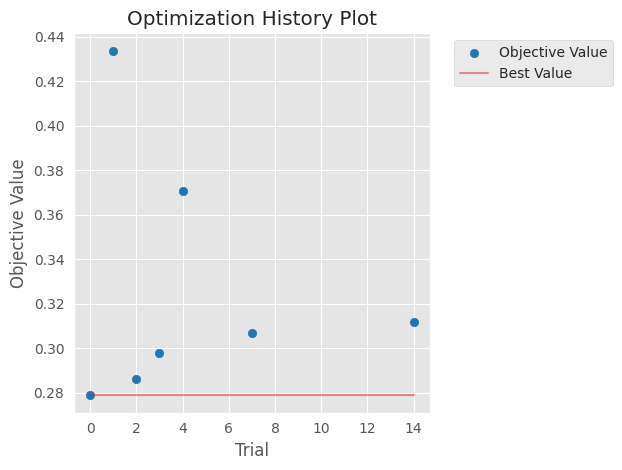

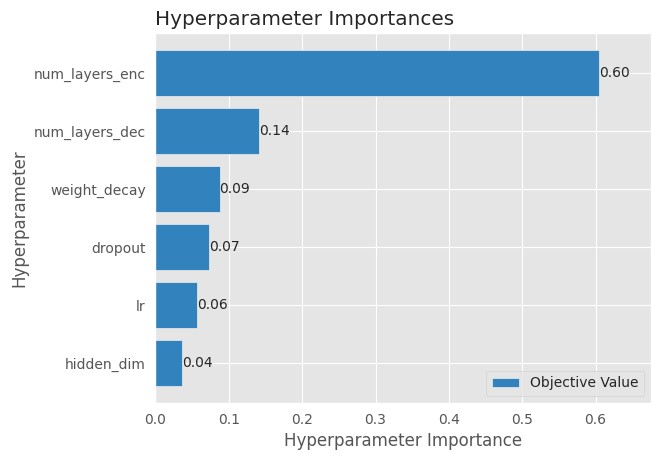

In [18]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
plot_optimization_history(study)
plt.show()
plot_param_importances(study)
plt.show()

In [16]:
# Cell 12: Final Training with Best Hyperparameters
# Train on NORMAL sequences only — this is the key constraint for the autoencoder approach.

print("Building final model with best hyperparameters...")
print(f"  hidden_dim={cfg.hidden_dim}, enc_layers={cfg.num_layers_enc},"
      f" dec_layers={cfg.num_layers_dec}, lr={cfg.learning_rate:.6f},"
      f" dropout={cfg.dropout}, weight_decay={cfg.weight_decay:.6f}")

raw_model = LSTMAutoencoder(
    n_features=cfg.n_features,
    hidden_dim=cfg.hidden_dim,
    num_layers_enc=cfg.num_layers_enc,
    num_layers_dec=cfg.num_layers_dec,
    dropout=cfg.dropout,
    seq_len=cfg.seq_len,
).to(device)

# Wrap with DataParallel if twin GPUs available (Kaggle T4 x2)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs with DataParallel")
    model = nn.DataParallel(raw_model)
else:
    model = raw_model

print(f"Parameters: {sum(p.numel() for p in raw_model.parameters()):,}")

optimizer = optim.AdamW(_unwrap(model).parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
criterion = nn.MSELoss()

# Train on normal-only sequences; validate on normal-only val sequences
# (to get a clean reconstruction loss signal)
train_loader = DataLoader(
    SequenceDataset(X_train_normal_norm, None),  # normal only!
    batch_size=cfg.batch_size, shuffle=True, num_workers=4, pin_memory=True,
)
val_loader = DataLoader(
    SequenceDataset(X_val_normal_norm, None),  # normal only for loss monitoring
    batch_size=cfg.batch_size, shuffle=False, num_workers=4, pin_memory=True,
)

print(f"\nTraining on {len(X_train_normal_norm):,} normal sequences")
print(f"Validating on {len(X_val_normal_norm):,} normal sequences (loss monitoring)")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
patience_counter = 0

for epoch in range(1, cfg.max_epochs + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _ = eval_epoch(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'model_state': _unwrap(model).state_dict(),  # safe with DataParallel
            'model_params': {
                'n_features': cfg.n_features,
                'hidden_dim': cfg.hidden_dim,
                'num_layers_enc': cfg.num_layers_enc,
                'num_layers_dec': cfg.num_layers_dec,
                'dropout': cfg.dropout,
                'seq_len': cfg.seq_len,
            },
            'optimizer_state': optimizer.state_dict(),
            'epoch': epoch,
            'val_loss': val_loss,
        }, os.path.join(cfg.model_dir, 'lstm_ae_best.pt'))
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= cfg.early_stopping_patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 5 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | lr={lr_now:.2e}")

print(f"\nBest val_loss: {best_val_loss:.6f}")

Building final model with best hyperparameters...
  hidden_dim=256, enc_layers=3, dec_layers=1, lr=0.000661, dropout=0.11742508365045984, weight_decay=0.000054
Using 2 GPUs with DataParallel
Parameters: 1,872,663

Training on 123,030 normal sequences
Validating on 40,500 normal sequences (loss monitoring)
Train batches: 241, Val batches: 80
Epoch   1 | train_loss=0.358526 | val_loss=0.305148 | lr=6.61e-04
Epoch   5 | train_loss=0.272575 | val_loss=0.269983 | lr=6.61e-04
Epoch  10 | train_loss=0.258283 | val_loss=0.258128 | lr=6.61e-04
Epoch  15 | train_loss=0.251641 | val_loss=0.251317 | lr=6.61e-04
Epoch  20 | train_loss=0.245081 | val_loss=0.244553 | lr=6.61e-04
Epoch  25 | train_loss=0.238100 | val_loss=0.237752 | lr=6.61e-04
Epoch  30 | train_loss=0.229329 | val_loss=0.228102 | lr=6.61e-04
Epoch  35 | train_loss=0.219821 | val_loss=0.218122 | lr=6.61e-04
Epoch  40 | train_loss=0.212848 | val_loss=0.211095 | lr=6.61e-04
Epoch  45 | train_loss=0.207696 | val_loss=0.208156 | lr=6.61e-

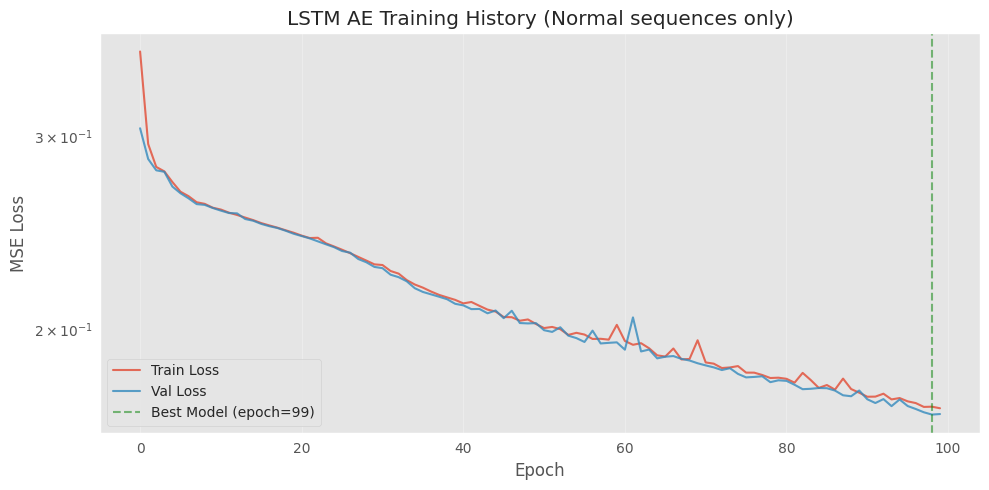

In [19]:
# Cell 13: Training History Plot
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss', alpha=0.8)
plt.plot(history['val_loss'], label='Val Loss', alpha=0.8)
best_epoch = np.argmin(history['val_loss'])
plt.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5,
            label=f'Best Model (epoch={best_epoch+1})')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('LSTM AE Training History (Normal sequences only)')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
# Cell 14: Threshold Calibration
# Load best model and compute reconstruction errors on FULL validation set
# (both normal and anomalous sequences) to find the optimal threshold.

checkpoint = torch.load(os.path.join(cfg.model_dir, 'lstm_ae_best.pt'), map_location='cpu')
model = LSTMAutoencoder(**checkpoint['model_params'])
model.load_state_dict(checkpoint['model_state'])
model = model.to(device)
model.eval()
criterion = nn.MSELoss()  # ensure criterion is defined in this scope
print(f"Loaded best model from epoch {checkpoint['epoch']}, val_loss={checkpoint['val_loss']:.6f}")

# Compute reconstruction errors on the FULL validation set (normal + anomalous)
val_loader_full = DataLoader(
    SequenceDataset(X_val_norm, None),  # all val sequences
    batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=True,
)
_, val_errors = eval_epoch(model, val_loader_full, criterion, device)

# Separate normal vs anomalous
normal_mask = y_val == 0
anom_mask = y_val == 1
val_errors_normal = val_errors[normal_mask]
val_errors_anom = val_errors[anom_mask]

print(f"Normal samples:    {len(val_errors_normal):,}, mean_err={val_errors_normal.mean():.6f}")
print(f"Anomalous samples: {len(val_errors_anom):,}, mean_err={val_errors_anom.mean():.6f}")
print(f"Separation ratio: {val_errors_anom.mean() / max(val_errors_normal.mean(), 1e-12):.2f}x")

# Find best threshold maximising F1
best_thresh, best_f1, all_errors, all_labels = find_best_threshold(
    val_errors_normal, val_errors_anom
)
print(f"\nBest threshold: {best_thresh:.6f} (F1={best_f1:.4f})")

# Also compute the 95th-percentile threshold on normal data (simpler alternative)
thresh_p95 = float(np.percentile(val_errors_normal, 95))
print(f"95th-pct threshold (normal only): {thresh_p95:.6f}")

# Compute AUROC and Average Precision
auroc = roc_auc_score(all_labels, all_errors)
ap = average_precision_score(all_labels, all_errors)
print(f"AUROC: {auroc:.4f}")
print(f"Avg Precision: {ap:.4f}")

Loaded best model from epoch 99, val_loss=0.167307
Normal samples:    40,500, mean_err=0.923179
Anomalous samples: 2,650, mean_err=23163918.000000
Separation ratio: 25091468.00x

Best threshold: 2.566275 (F1=0.7783)
95th-pct threshold (normal only): 1.715169
AUROC: 0.7068
Avg Precision: 0.6830


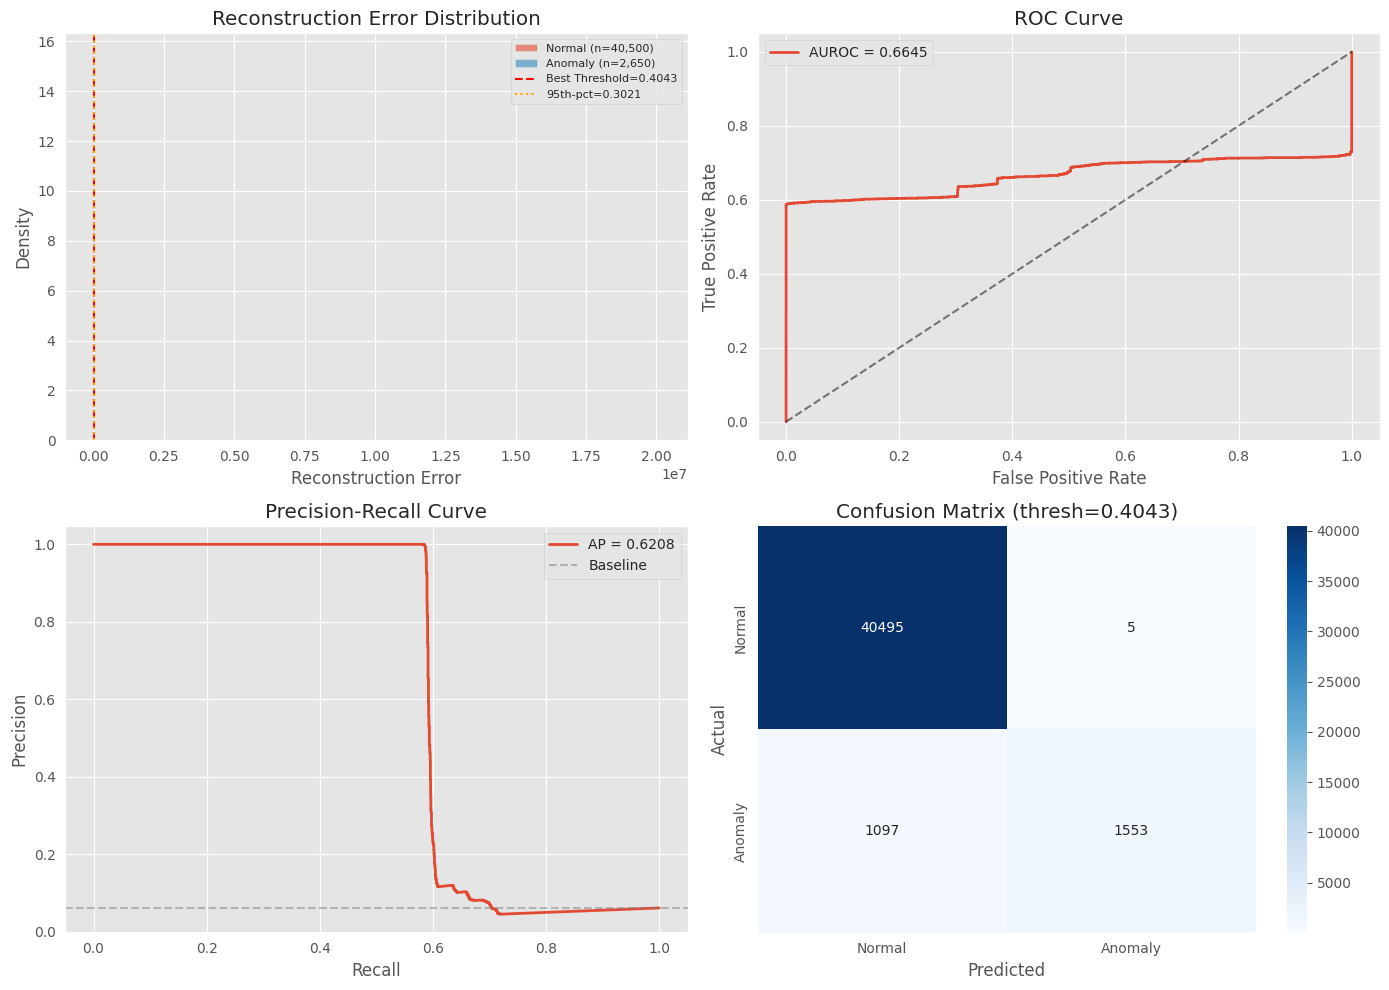


Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      1.00      0.99     40500
     Anomaly       1.00      0.59      0.74      2650

    accuracy                           0.97     43150
   macro avg       0.99      0.79      0.86     43150
weighted avg       0.98      0.97      0.97     43150



In [21]:
# Cell 15: Evaluation Plots

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# — 15a: Reconstruction error distributions
ax = axes[0, 0]
ax.hist(val_errors_normal, bins=100, alpha=0.6, label=f'Normal (n={len(val_errors_normal):,})', density=True)
ax.hist(val_errors_anom, bins=100, alpha=0.6, label=f'Anomaly (n={len(val_errors_anom):,})', density=True)
ax.axvline(best_thresh, color='red', linestyle='--', label=f'Best Threshold={best_thresh:.4f}')
ax.axvline(thresh_p95, color='orange', linestyle=':', label=f'95th-pct={thresh_p95:.4f}')
ax.set_xlabel('Reconstruction Error')
ax.set_ylabel('Density')
ax.set_title('Reconstruction Error Distribution')
ax.legend(fontsize=8)

# — 15b: ROC Curve
ax = axes[0, 1]
fpr, tpr, _ = roc_curve(all_labels, all_errors)
ax.plot(fpr, tpr, lw=2, label=f'AUROC = {auroc:.4f}')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()

# — 15c: Precision-Recall Curve
ax = axes[1, 0]
precisions, recalls, _ = precision_recall_curve(all_labels, all_errors)
ax.plot(recalls, precisions, lw=2, label=f'AP = {ap:.4f}')
ax.axhline(y=all_labels.mean(), color='gray', linestyle='--', alpha=0.5, label='Baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve')
ax.legend()

# — 15d: Confusion Matrix at best threshold
ax = axes[1, 1]
preds = (all_errors >= best_thresh).astype(int)
cm = confusion_matrix(all_labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (thresh={best_thresh:.4f})')

plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(all_labels, preds, target_names=['Normal', 'Anomaly']))

Per-Fault-Type Reconstruction Error:
  none                : mean_err=0.9232, median=0.8026, detection_rate=0.07%, n=40,500
  congestion          : mean_err=6017.7778, median=2.4419, detection_rate=49.64%, n=280
  bgp_flap            : mean_err=908667.1875, median=68667.7188, detection_rate=72.88%, n=520
  mpls_failure        : mean_err=32924430.0000, median=12332.5938, detection_rate=64.22%, n=1,850


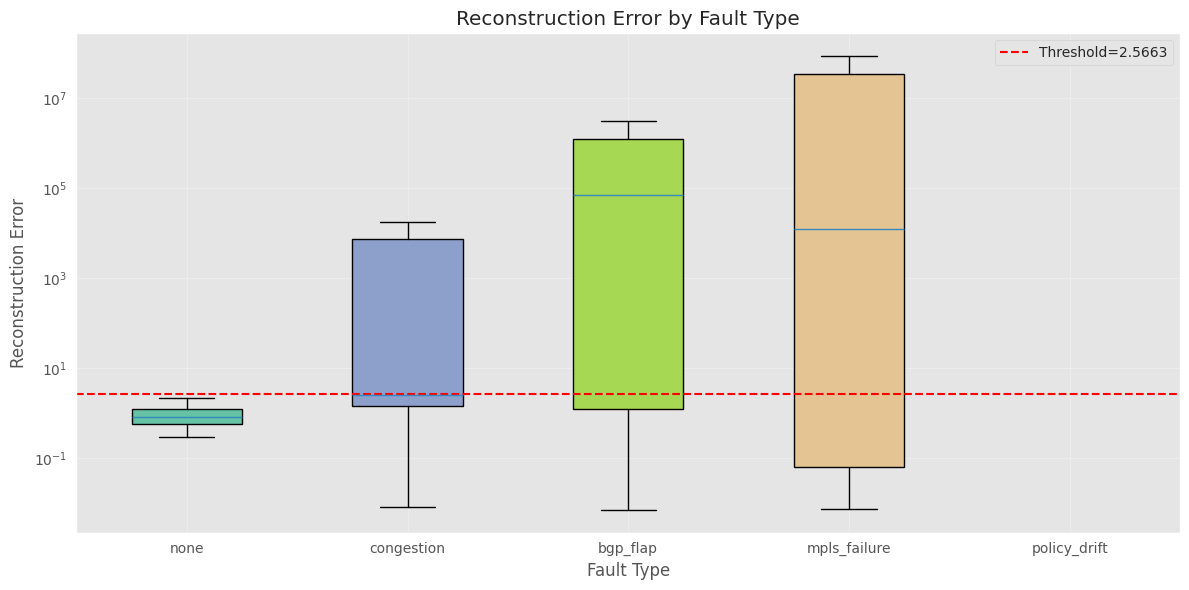

In [38]:
# Cell 16: Per-Fault-Type Analysis

def majority_fault(fault_array):
    non_normal = [f for f in fault_array if f != 'none']
    if not non_normal:
        return 'none'
    return Counter(non_normal).most_common(1)[0][0]

seq_fault_types = [majority_fault(fa) for fa in fault_val]

fault_type_errors = {}
for ft, err in zip(seq_fault_types, val_errors):
    fault_type_errors.setdefault(ft, []).append(err)

print("Per-Fault-Type Reconstruction Error:")
fault_order = ['none', 'congestion', 'bgp_flap', 'mpls_failure', 'policy_drift']
for ft in fault_order:
    if ft in fault_type_errors:
        errs = np.array(fault_type_errors[ft])
        detection_rate = (errs >= best_thresh).mean()
        print(f"  {ft:20s}: mean_err={errs.mean():.4f}, median={np.median(errs):.4f}, "
              f"detection_rate={detection_rate:.2%}, n={len(errs):,}")

# Box plot by fault type
plt.figure(figsize=(12, 6))
data_to_plot = [np.array(fault_type_errors.get(ft, [0])) for ft in fault_order]
bp = plt.boxplot(data_to_plot, labels=fault_order, showfliers=False, patch_artist=True)
colors = plt.cm.Set2(np.linspace(0, 1, len(fault_order)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
plt.axhline(y=best_thresh, color='red', linestyle='--', label=f'Threshold={best_thresh:.4f}')
plt.xlabel('Fault Type')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error by Fault Type')
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Per-Node Anomaly Detection Performance:
  CE-B1: AUROC=0.3025, AP=0.3139, F1=0.4375, n=4,315 (anom=250)
  CE-B2: AUROC=0.4047, AP=0.4277, F1=0.5057, n=4,315 (anom=390)
  CE-B3: AUROC=0.2994, AP=0.3087, F1=0.4375, n=4,315 (anom=250)
  CE-DC1: AUROC=0.2051, AP=0.1867, F1=0.2381, n=4,315 (anom=185)
  CE-DC2: AUROC=0.9973, AP=0.9885, F1=0.2870, n=4,315 (anom=185)
  P-1: AUROC=0.9162, AP=0.9171, F1=0.9518, n=4,315 (anom=250)
  P-2: AUROC=0.9258, AP=0.9217, F1=0.9540, n=4,315 (anom=250)
  P-3: AUROC=0.9217, AP=0.9181, F1=0.9540, n=4,315 (anom=250)
  PE-1: AUROC=0.8302, AP=0.8329, F1=0.8873, n=4,315 (anom=390)
  PE-2: AUROC=0.9107, AP=0.9133, F1=0.9518, n=4,315 (anom=250)


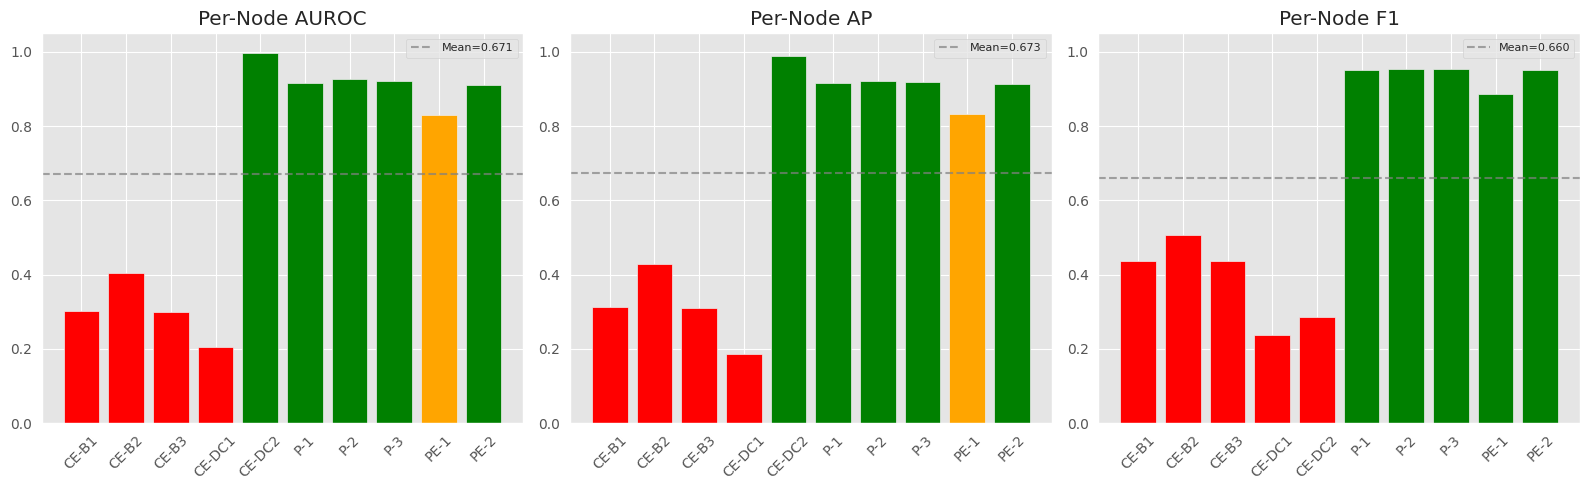

In [23]:
# Cell 17: Per-Node Performance

print("Per-Node Anomaly Detection Performance:")
node_results = []
nodes_val_arr = np.array(nodes_val)
for nid in sorted(set(nodes_val)):
    mask = nodes_val_arr == nid
    node_errs = val_errors[mask]
    node_labels = y_val[mask]
    if len(node_labels) < 10 or len(np.unique(node_labels)) < 2:
        continue
    auroc_node = roc_auc_score(node_labels, node_errs)
    ap_node = average_precision_score(node_labels, node_errs)
    node_preds = (node_errs >= best_thresh).astype(int)
    f1 = 2 * (node_preds * node_labels).sum() / max((node_preds + node_labels).sum(), 1)
    node_results.append({'node_id': nid, 'auroc': auroc_node, 'ap': ap_node, 'f1': f1,
                         'n_normal': (node_labels == 0).sum(), 'n_anom': (node_labels == 1).sum()})
    print(f"  {nid}: AUROC={auroc_node:.4f}, AP={ap_node:.4f}, F1={f1:.4f}, "
          f"n={len(node_labels):,} (anom={node_labels.sum():,})")

if node_results:
    node_df = pd.DataFrame(node_results).set_index('node_id')
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for i, col in enumerate(['auroc', 'ap', 'f1']):
        colors = ['red' if v < 0.7 else 'orange' if v < 0.85 else 'green' for v in node_df[col]]
        axes[i].bar(node_df.index, node_df[col], color=colors)
        axes[i].set_title(f'Per-Node {col.upper()}')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylim(0, 1.05)
        axes[i].axhline(y=node_df[col].mean(), color='gray', linestyle='--', alpha=0.7,
                        label=f'Mean={node_df[col].mean():.3f}')
        axes[i].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

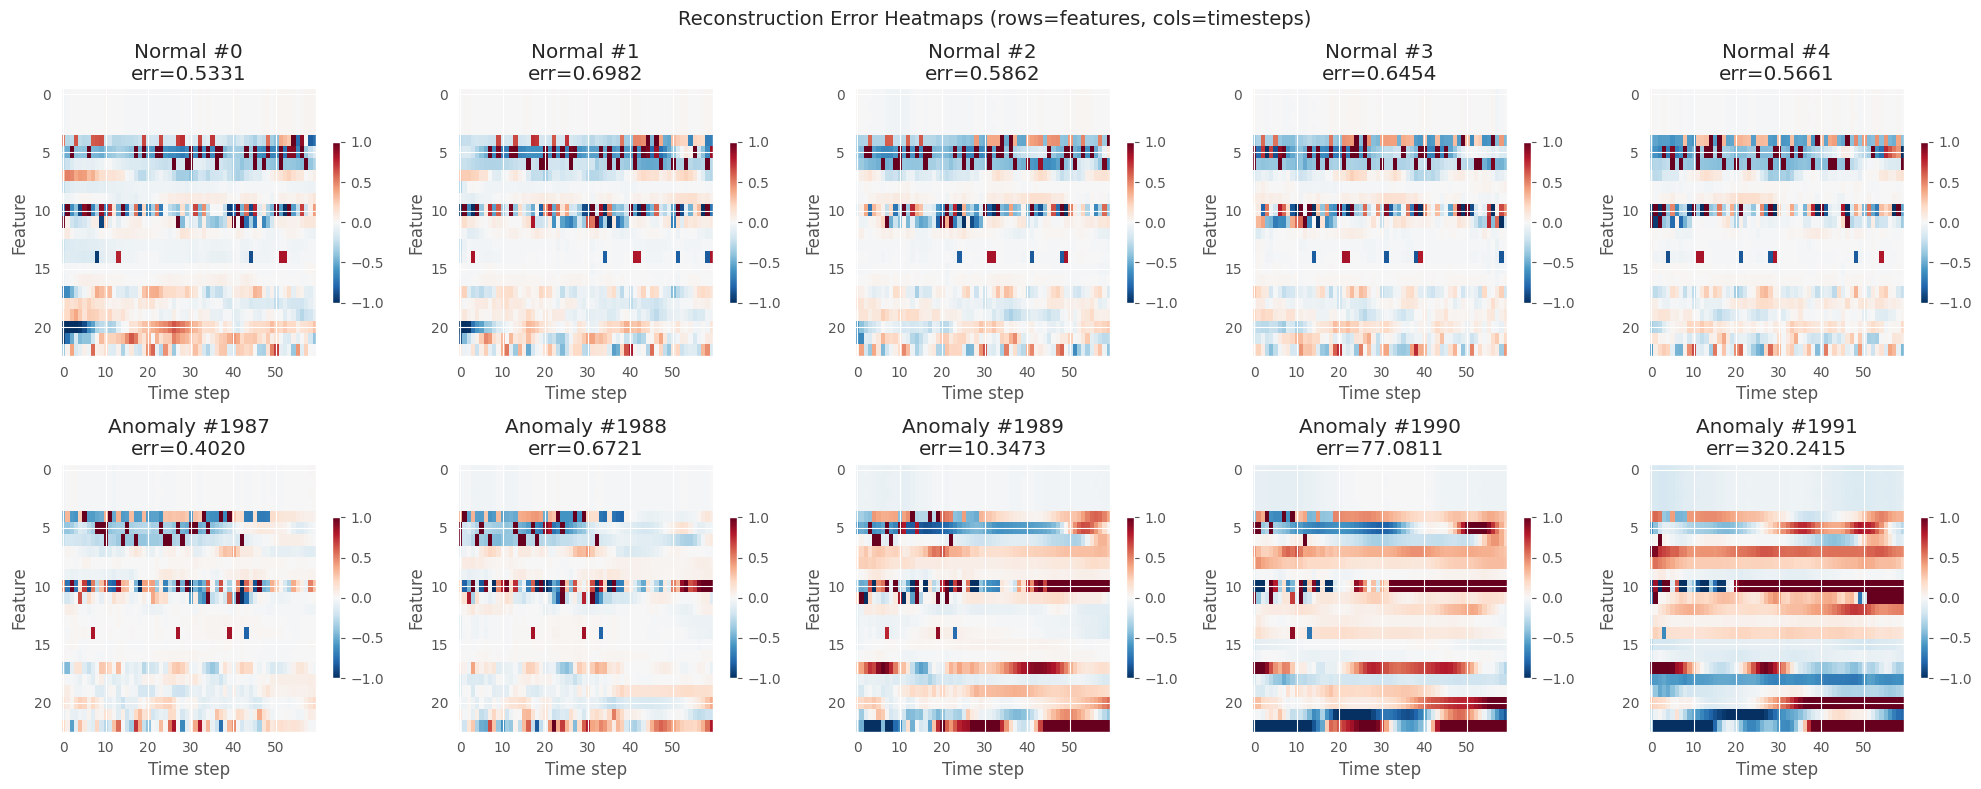

In [39]:
# Cell 18: Sample Reconstruction Visualization

# Pick a few normal and anomalous sequences from validation set
normal_idx = np.where(y_val == 0)[0][:5]
anom_idx = np.where(y_val == 1)[0][:5]

model.eval()
with torch.no_grad():
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))

    # Normal samples
    for i, idx in enumerate(normal_idx):
        x = torch.FloatTensor(X_val_norm[idx:idx+1]).to(device)
        x_hat = model(x)
        err = (x - x_hat).cpu().numpy()[0]
        ax = axes[0, i]
        im = ax.imshow(err.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
        ax.set_title(f'Normal #{idx}\nerr={val_errors[idx]:.4f}')
        ax.set_xlabel('Time step')
        ax.set_ylabel('Feature')
        plt.colorbar(im, ax=ax, shrink=0.6)

    # Anomalous samples
    for i, idx in enumerate(anom_idx):
        x = torch.FloatTensor(X_val_norm[idx:idx+1]).to(device)
        x_hat = model(x)
        err = (x - x_hat).cpu().numpy()[0]
        ax = axes[1, i]
        im = ax.imshow(err.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
        ax.set_title(f'Anomaly #{idx}\nerr={val_errors[idx]:.4f}')
        ax.set_xlabel('Time step')
        ax.set_ylabel('Feature')
        plt.colorbar(im, ax=ax, shrink=0.6)

    plt.suptitle('Reconstruction Error Heatmaps (rows=features, cols=timesteps)', fontsize=14)
    plt.tight_layout()
    plt.show()

In [40]:
# Cell 19: Save Final Model & Download

final_path = os.path.join(cfg.model_dir, 'lstm_ae.pt')
torch.save({
    'model_state': _unwrap(model).state_dict(),  # safe with DataParallel
    'model_params': {
        'n_features': cfg.n_features,
        'hidden_dim': cfg.hidden_dim,
        'num_layers_enc': cfg.num_layers_enc,
        'num_layers_dec': cfg.num_layers_dec,
        'dropout': cfg.dropout,
        'seq_len': cfg.seq_len,
    },
    'threshold': best_thresh,
    'threshold_p95': thresh_p95,
    'val_auroc': auroc,
    'val_ap': ap,
    'val_f1': best_f1,
    'numeric_cols': cfg.numeric_cols,
}, final_path)
print(f"Final model saved to {final_path}")
print(f"  n_features={cfg.n_features}, hidden_dim={cfg.hidden_dim}")
print(f"  seq_len={cfg.seq_len}, threshold={best_thresh:.6f}")
print(f"  Val AUROC={auroc:.4f}, AP={ap:.4f}, F1={best_f1:.4f}")

# Verify the saved model loads correctly
print("\nVerifying saved model...")
# verify = torch.load(final_path, map_location='cpu')
verify = torch.load(final_path, map_location='cpu', weights_only=False)
verify_model = LSTMAutoencoder(**verify['model_params'])
verify_model.load_state_dict(verify['model_state'])
print(f"  model_params: {verify['model_params']}")
print(f"  threshold: {verify['threshold']:.6f}")
print(f"  val_auroc: {verify['val_auroc']:.4f}")
print("  Model loads correctly ✓")
del verify_model

# Create a zip for easy download from Kaggle Output tab
zip_path = os.path.join(cfg.model_dir, 'lstm_ae_model.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(final_path, 'lstm_ae.pt')
    zf.write(scaler_path, 'lstm_scaler.pkl')
print(f"\nZip created: {zip_path} ({os.path.getsize(zip_path) / 1024 / 1024:.1f} MB)")

# In Kaggle, use the Output tab or:
from IPython.display import FileLink
display(FileLink(zip_path))

Final model saved to /kaggle/working/lstm_ae.pt
  n_features=23, hidden_dim=256
  seq_len=60, threshold=2.566275
  Val AUROC=0.7068, AP=0.6830, F1=0.7783

Verifying saved model...
  model_params: {'n_features': 23, 'hidden_dim': 256, 'num_layers_enc': 3, 'num_layers_dec': 1, 'dropout': 0.11742508365045984, 'seq_len': 60}
  threshold: 2.566275
  val_auroc: 0.7068
  Model loads correctly ✓

Zip created: /kaggle/working/lstm_ae_model.zip (6.6 MB)


/kaggle/working/lstm_ae_model.zip

In [41]:
# Cell 20: Summary & Model Card
print("=" * 60)
print("LSTM AUTOENCODER — TRAINING SUMMARY")
print("=" * 60)
print(f"\nDataset:")
print(f"  Total train sequences:  {len(X_train_raw):,}")
print(f"  Normal train (AE train):{len(X_train_normal_norm):,}")
print(f"  Val sequences:          {len(X_val_norm):,}")
print(f"  Sequence length:        {cfg.seq_len} timesteps ({cfg.seq_len * 2}s = {cfg.seq_len * 2 / 60:.1f} min)")
print(f"  Features:               {cfg.n_features} numeric columns")
print(f"\nFinal Hyperparameters (after Optuna tuning):")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nValidation Performance:")
print(f"  AUROC:              {auroc:.4f}")
print(f"  Average Precision:  {ap:.4f}")
print(f"  Best F1:            {best_f1:.4f}")
print(f"  Best Threshold:     {best_thresh:.6f}")
print(f"\nModel File: lstm_ae.pt ({os.path.getsize(final_path) / 1024:.1f} KB)")
print(f"Scaler File: lstm_scaler.pkl")
print("=" * 60)
print("\nHow to use in inference:")
print('''
  checkpoint = torch.load('lstm_ae.pt', map_location='cpu')
  model = LSTMAutoencoder(**checkpoint['model_params'])
  model.load_state_dict(checkpoint['model_state'])
  model.eval()

  scaler = joblib.load('lstm_scaler.pkl')
  # sequence: (seq_len, n_features) raw values
  seq_norm = scaler.transform(sequence.reshape(-1, n_features)).reshape(1, seq_len, n_features)
  seq_tensor = torch.FloatTensor(seq_norm)
  with torch.no_grad():
      err = model.reconstruction_error(seq_tensor).item()
  is_anomaly = err > checkpoint['threshold']
  lstm_score = min(err / (3 * checkpoint['threshold']), 1.0)
''')

print("\nDone. Ready to download from Output tab.")
print("Files to download:")
print(f"  1. {final_path}")
print(f"  2. {scaler_path}")
print(f"  3. {zip_path}")

LSTM AUTOENCODER — TRAINING SUMMARY

Dataset:
  Total train sequences:  129,550
  Normal train (AE train):123,030
  Val sequences:          43,150
  Sequence length:        60 timesteps (120s = 2.0 min)
  Features:               23 numeric columns

Final Hyperparameters (after Optuna tuning):
  hidden_dim: 256
  num_layers_enc: 3
  num_layers_dec: 1
  lr: 0.0006612372870684138
  dropout: 0.11742508365045984
  weight_decay: 5.39948440978744e-05

Validation Performance:
  AUROC:              0.7068
  Average Precision:  0.6830
  Best F1:            0.7783
  Best Threshold:     2.566275

Model File: lstm_ae.pt (7319.8 KB)
Scaler File: lstm_scaler.pkl

How to use in inference:

  checkpoint = torch.load('lstm_ae.pt', map_location='cpu')
  model = LSTMAutoencoder(**checkpoint['model_params'])
  model.load_state_dict(checkpoint['model_state'])
  model.eval()

  scaler = joblib.load('lstm_scaler.pkl')
  # sequence: (seq_len, n_features) raw values
  seq_norm = scaler.transform(sequence.reshap